<a href="https://colab.research.google.com/github/tinytechtree/feedermap/blob/main/Workshop_Demo_3_Langgraph_Single_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

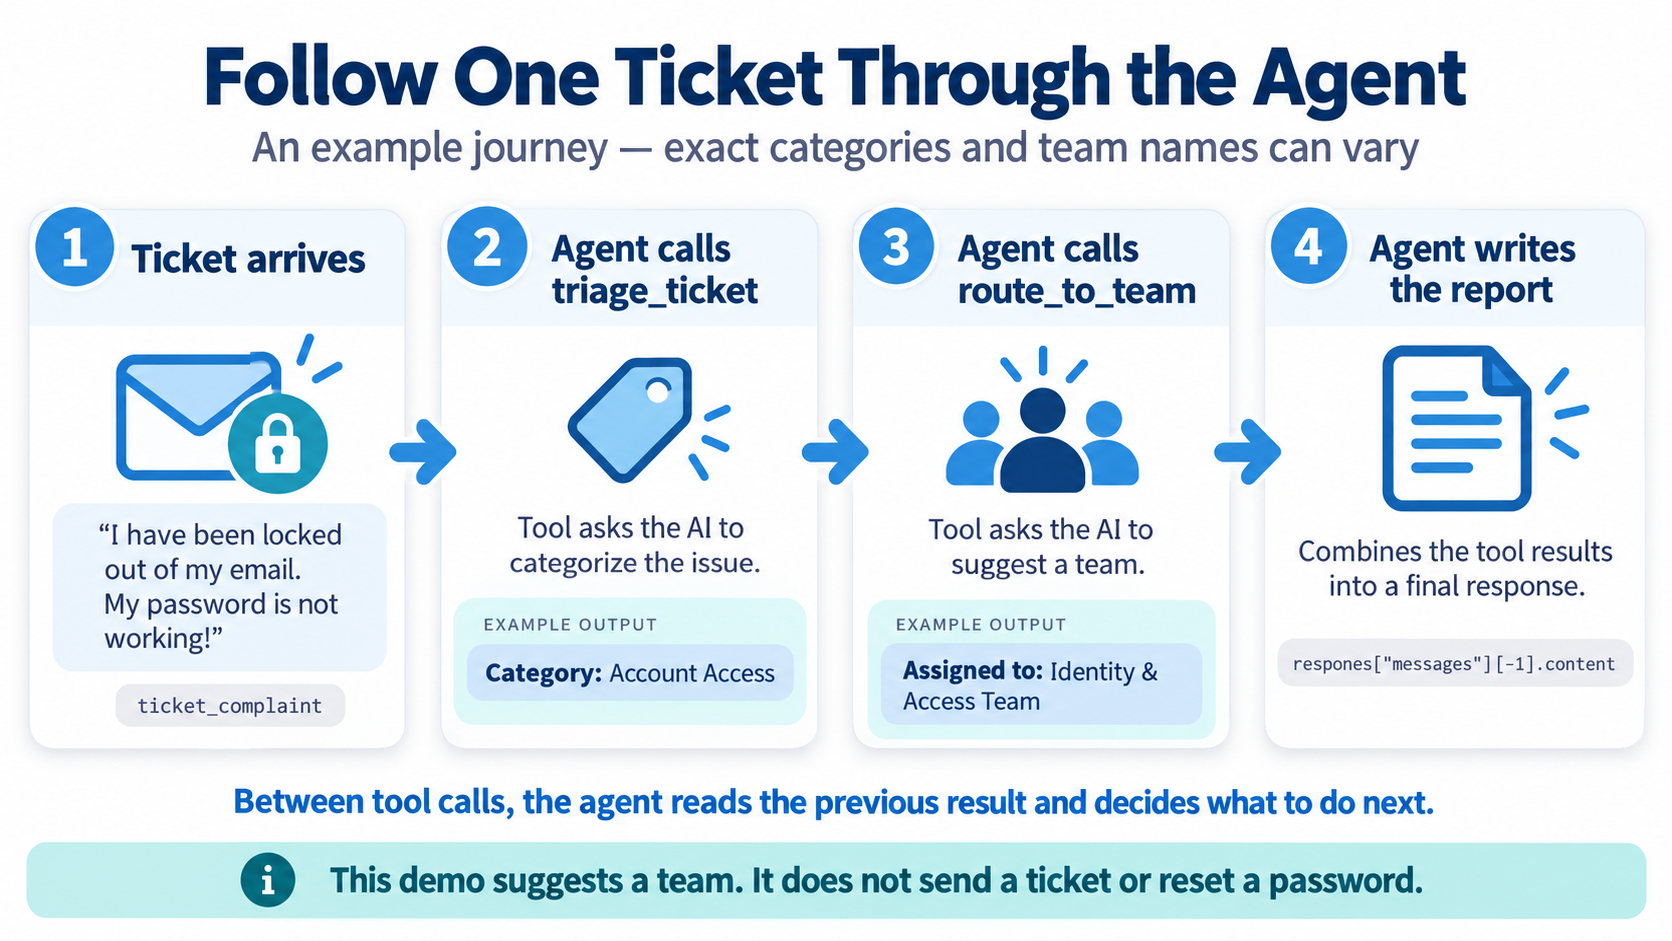

In [ ]:
%pip install langchain_core langgraph langchain-groq --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.3 MB/s eta 0:00:00


In [ ]:
from langchain.agents import create_agent

# 2. Import the library
from langchain_groq import ChatGroq

In [ ]:
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

# Assuming llm is already defined in a previous cell. If not, it will need to be re-initialized here.
# For now, I'll assume it's globally available or passed in if the tools were refactored as classes.
# Since the user asked to modify the existing notebook, I'll rely on the llm being available from 'TiJbsajuvbWo'.

# Re-initializing LLM here with a max_tokens limit to avoid RateLimitError
# Note: This will override the `llm` object defined in the previous cell for the scope of this cell.
llm = ChatGroq(
    api_key="YOUR API KEY HERE", # <<< REPLACE WITH YOUR ACTUAL GROQ API KEY >>>
    model="openai/gpt-oss-120b",
    max_tokens=500 # Limit output tokens to prevent RateLimitError
)

# 2. Tool 1: Triage the ticket
@tool
def triage_ticket(issue_text: str) -> str:
    """Categorizes the IT issue based on the text."""
    global llm # Access the LLM defined in the other cell

    triage_prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an expert IT support agent. Categorize the following IT issue. Only respond with the category name."),
        ("user", "IT Issue: {issue_text}")
    ])
    chain = triage_prompt | llm
    response = chain.invoke({"issue_text": issue_text})
    return f"Category: {response.content.strip()}"

# 3. Tool 2: Route the ticket to the right team
@tool
def route_to_team(category: str) -> str:
    """Finds the right IT team to fix the issue based on the category."""
    global llm # Access the LLM defined in the other cell

    route_prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an expert IT support agent. Given the IT issue category, assign it to the appropriate team. Only respond with the team name."),
        ("user", "Category: {category}")
    ])
    chain = route_prompt | llm
    response = chain.invoke({"category": category})
    return f"Assigned to: {response.content.strip()}"

# 2. Group our tools from yesterday into a list
my_it_tools = [triage_ticket, route_to_team]

# 3. Create the Autonomous Agent!
agent_executor = create_agent(llm, tools=my_it_tools)


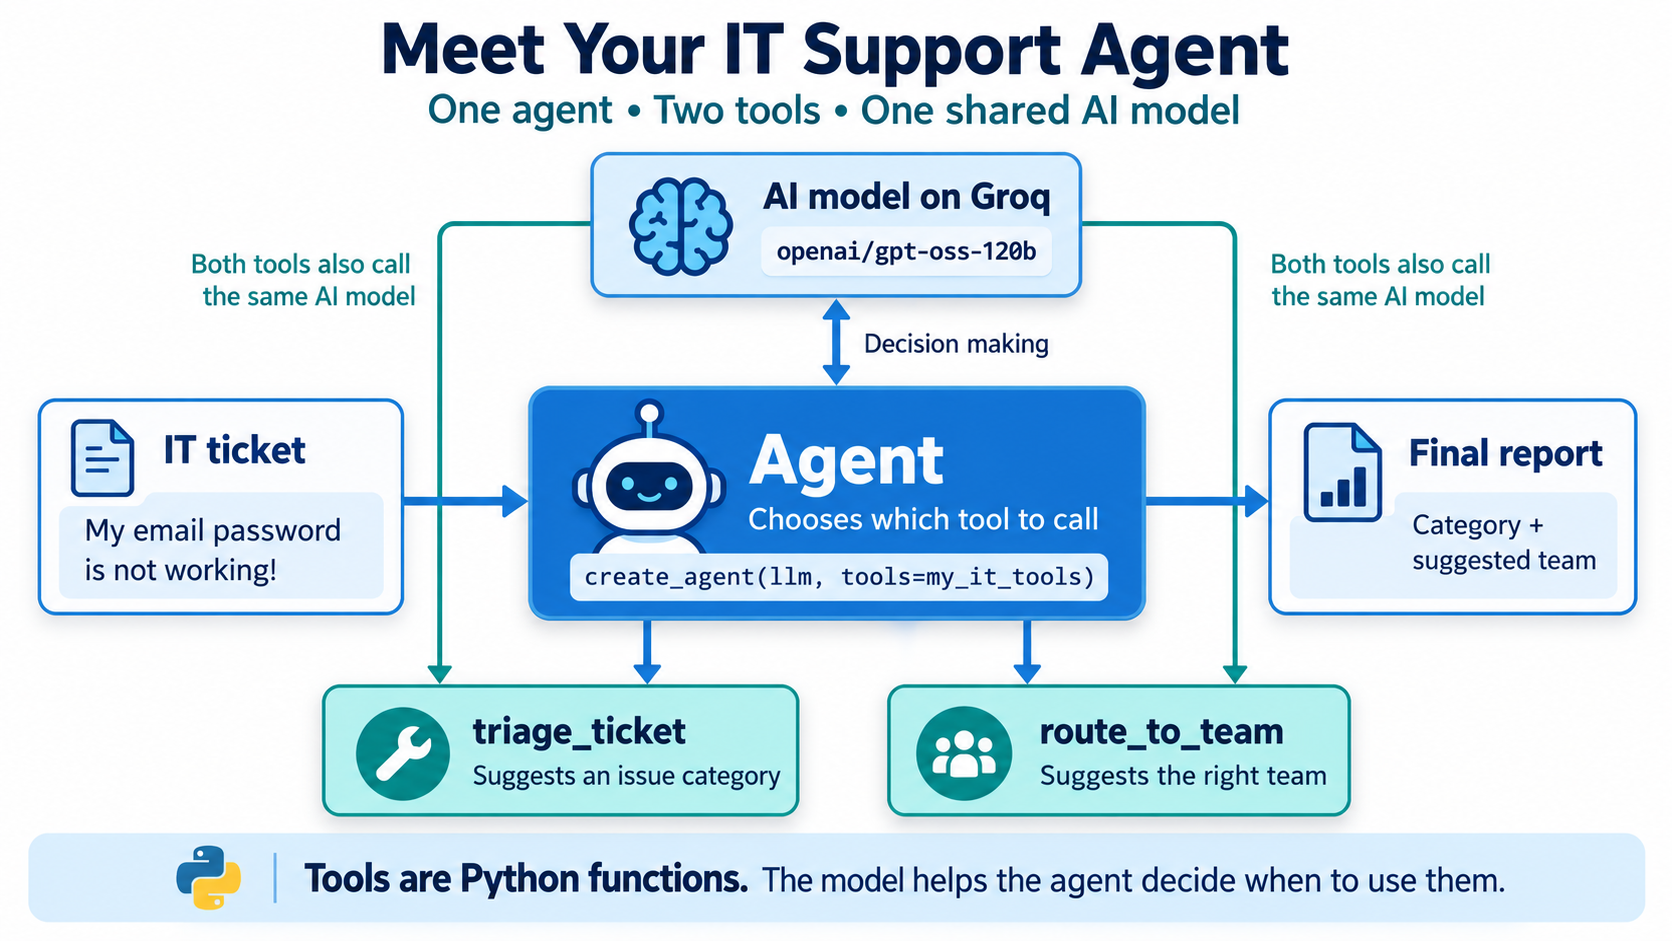

In [ ]:
# 4. Give the Agent a simulated IT ticket
ticket_complaint = "I have been locked out of my email. My password is not working!"

print(f"📩 NEW TICKET RECEIVED: '{ticket_complaint}'\n")

# 5. Tell the agent to process the ticket
response = agent_executor.invoke({"messages": [("user", f"Please process this ticket: {ticket_complaint}")]})

# 6. Read the final output from the agent
print("🤖 AGENT FINAL REPORT:")
print(response["messages"][-1].content)

📩 NEW TICKET RECEIVED: 'I have been locked out of my email. My password is not working!'

🤖 AGENT FINAL REPORT:
Your request has been logged and routed to the Help Desk. They’ll reach out shortly to help you reset your password and regain access to your email. If you have any additional details (e.g., the email address affected or recent password changes), feel free to let us know.


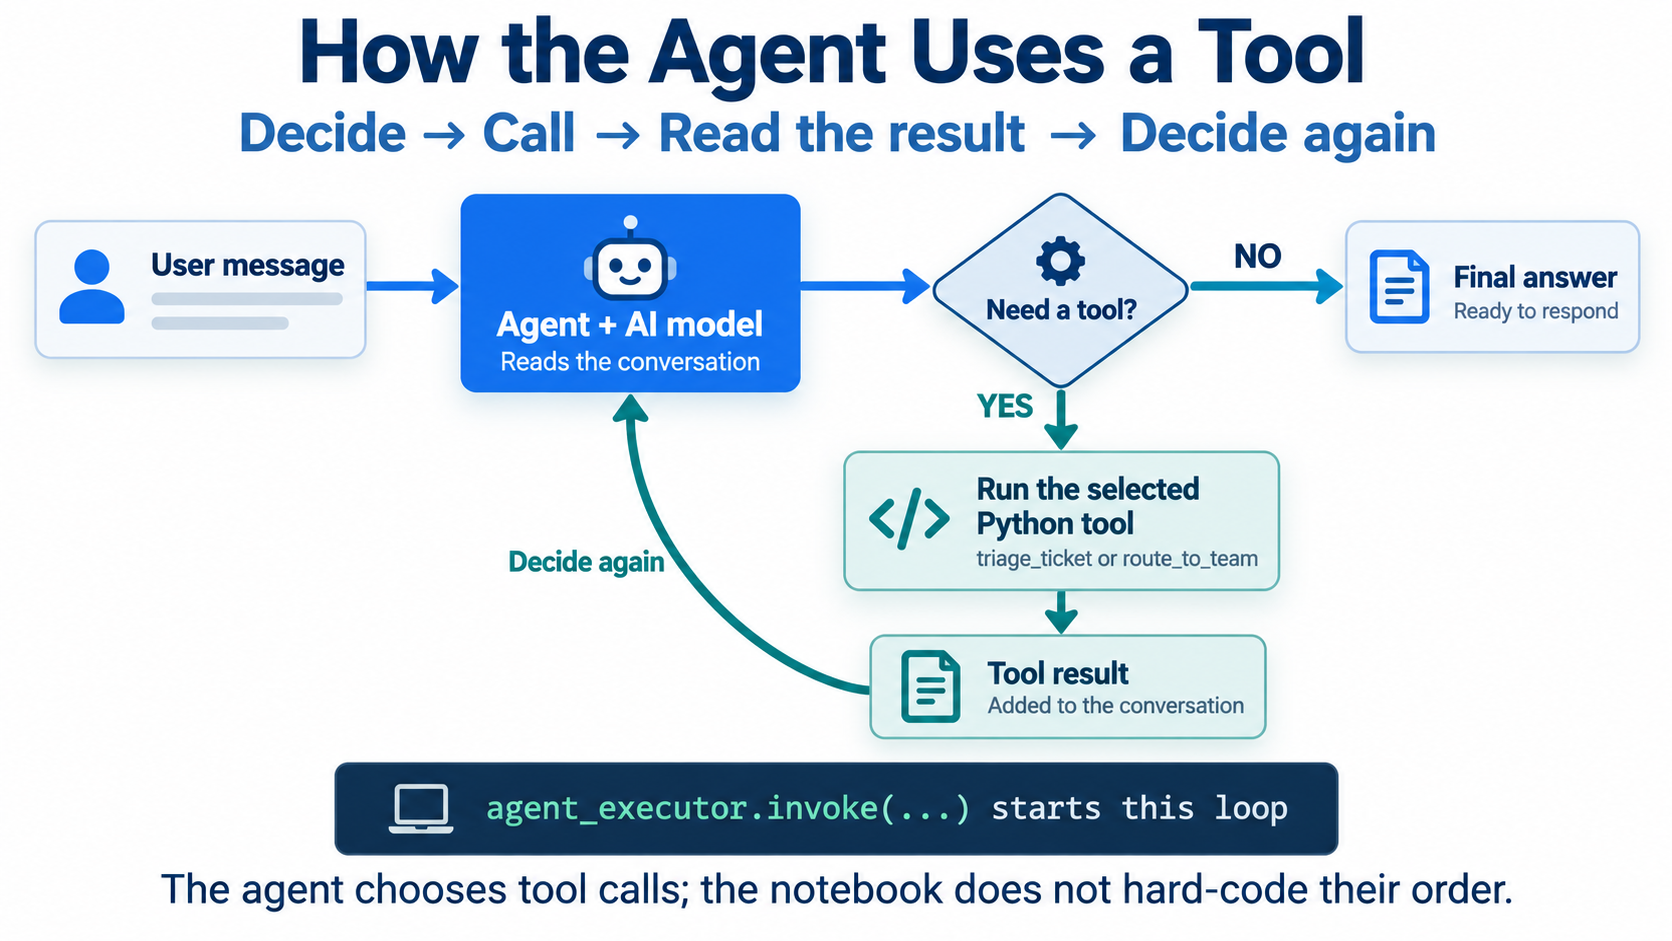